# Analysis of LASSO

## Workflow:

1. Library Imports
2. Data Loading & Preprocessing
3. Model Definition
4. Evaluation and Visualization

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [37]:
#Data preparation
data_AD_original = pd.read_csv("data.ttest_AD_original.csv")  
data_ALS_original = pd.read_csv("data.ttest_ALS_original.csv")
data_PD_original = pd.read_csv("data.ttest_PD_original.csv")


In [38]:
#Diagnosis column
v_1 = data_AD_original['diagnosis'].unique()
print("AD original:")
print(v_1)
v_2 = data_ALS_original['diagnosis'].unique()
print("ALS original:")
print(v_2)
v_3 = data_PD_original['diagnosis'].unique()
print("PD original:")
print(v_3)

AD original:
['Control' 'AD']
ALS original:
['ALS' 'CON']
PD original:
['CONTROL' 'IPD']


In [39]:
# Convert the column 'diagnosis' a binario: 0 = Control, 1 = AD
data_AD_original['class'] = data_AD_original['diagnosis'].apply(lambda x: 1 if x == 'AD' else 0)
print(data_AD_original['class'].value_counts())
print(data_AD_original['class'].value_counts(normalize=True))

class
0    249
1    204
Name: count, dtype: int64
class
0    0.549669
1    0.450331
Name: proportion, dtype: float64


In [40]:
# Convert the column 'diagnosis' a binario: 0 = Control, 1 = ALS
data_ALS_original['class'] = data_ALS_original['diagnosis'].apply(lambda x: 1 if x == 'ALS' else 0)
print(data_ALS_original['class'].value_counts())
print(data_ALS_original['class'].value_counts(normalize=True))

class
0    508
1    233
Name: count, dtype: int64
class
0    0.68556
1    0.31444
Name: proportion, dtype: float64


In [41]:
# Convert the column 'diagnosis' a binario: 0 = Control, 1 = PD
data_PD_original['class'] = data_PD_original['diagnosis'].apply(lambda x: 1 if x == 'IPD' else 0)
print(data_PD_original['class'].value_counts())
print(data_PD_original['class'].value_counts(normalize=True))

class
0    233
1    205
Name: count, dtype: int64
class
0    0.531963
1    0.468037
Name: proportion, dtype: float64


 Evaluation model: AD 

Metrics for AD (from CV predictions):
Accuracy: 0.587
Precision: 0.536
Recall (Sensitivity): 0.618
F1 Score: 0.574
Specificity: 0.562
AUC for AD: 0.631

 Evaluation model: ALS 

Metrics for ALS (from CV predictions):
Accuracy: 0.784
Precision: 0.628
Recall (Sensitivity): 0.768
F1 Score: 0.691
Specificity: 0.791
AUC for ALS: 0.857

 Evaluation model: PD 

Metrics for PD (from CV predictions):
Accuracy: 0.603
Precision: 0.578
Recall (Sensitivity): 0.561
F1 Score: 0.569
Specificity: 0.639
AUC for PD: 0.617



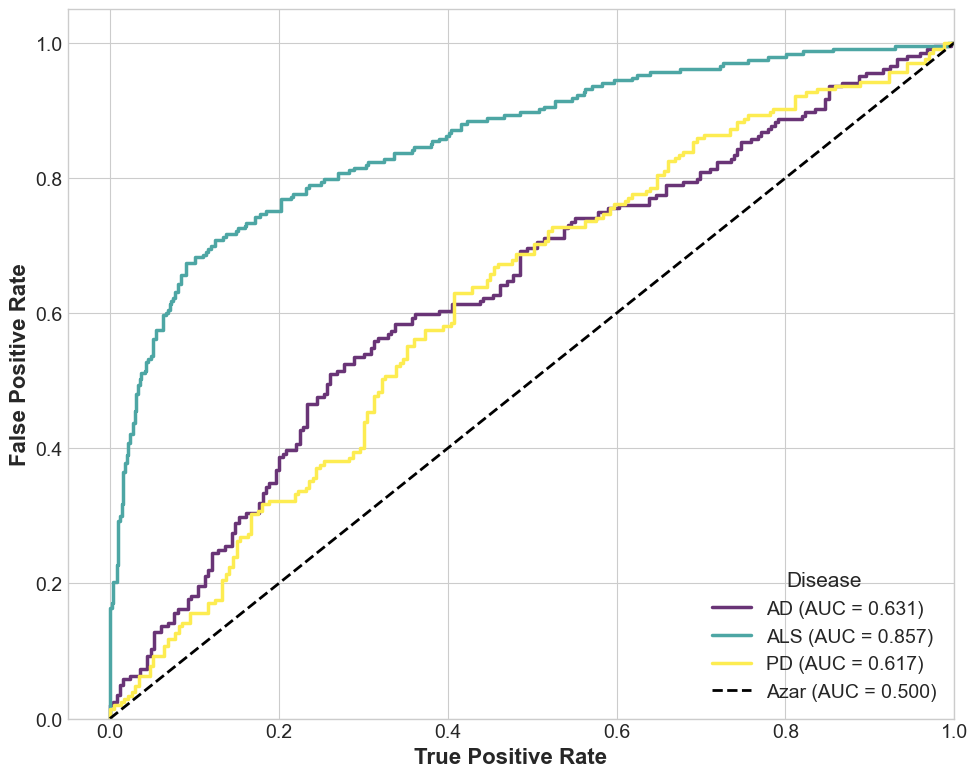

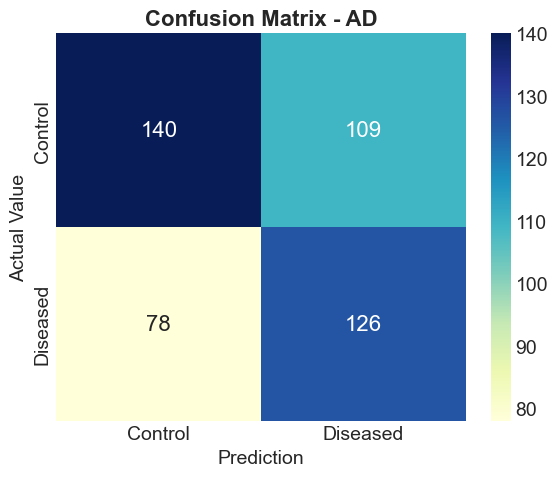

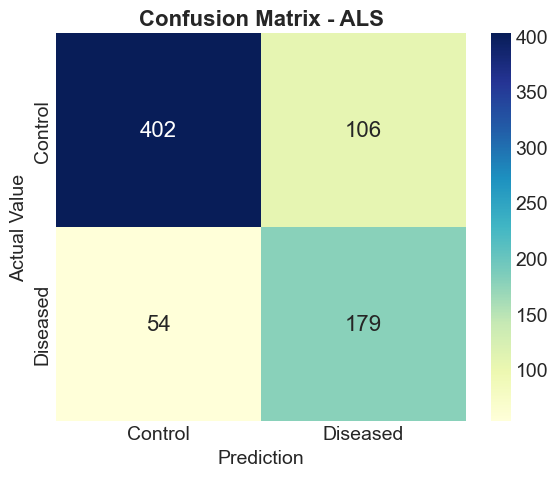

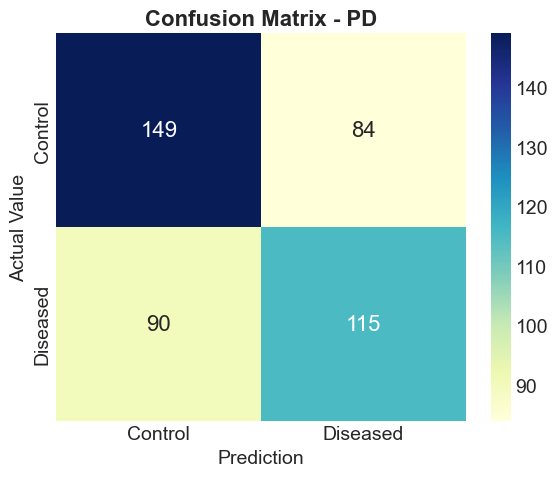



 Final Model Coefficients for: AD ---

Top Genes Selected by Final AD LASSO Model:
(Best C found by CV: 79.0604)
RPS6KB1: 0.7001
TAX1BP1: -0.6115
RPL22: -0.5097
RPL15: 0.4417
HCLS1: 0.3984
VAV1: 0.3686
FOS: 0.3625
C5AR1: -0.2974
NKTR: -0.2771
MYO1F: -0.2452
RBM25: -0.2425
TLN1: -0.1718
EIF4A2: -0.1190
ITGAM: 0.1128
NCF4: 0.0988
TPT1: -0.0944
LILRB2: -0.0127


 Final Model Coefficients for: ALS ---

Top Genes Selected by Final ALS LASSO Model:
(Best C found by CV: 0.4942)
CTSS: 0.8534
CSF1R: -0.8222
C5AR1: 0.8024
RPS6KB1: 0.6709
PTEN: -0.6709
TLN1: 0.6175
IL18: -0.5607
TNFSF13B: 0.4048
TAX1BP1: -0.2883
RPL22: 0.2853
TPT1: 0.2586
LILRB2: 0.2189
FOS: -0.2093
NKTR: 0.1632
EIF4A2: 0.1532
PTPRC: -0.0187
RBM25: 0.0120


 Final Model Coefficients for: PD ---

Top Genes Selected by Final PD LASSO Model:
(Best C found by CV: 0.1600)
NCF4: 0.1677
CSF1R: 0.1578
C5AR1: 0.1328
PTPRC: -0.1115
IL18: 0.0873
LILRB2: 0.0858
CTSS: 0.0425
MYO1F: 0.0176
PTEN: -0.0065


In [42]:
# Definition of data and genes
genes_AD = ['LILRB2','TLN1','ITGAM','C5AR1','RPL15','FOS','EIF4A2','NKTR','TPT1','RBM25','RPL22','TAX1BP1','RPS6KB1','NCF4','MYO1F','VAV1','HCLS1']
genes_ALS = ['LILRB2','TLN1','ITGAM','C5AR1','RPL15','FOS','EIF4A2','NKTR','TPT1','RBM25','RPL22','TAX1BP1','RPS6KB1','IL18','PTPRC','PTEN','CTSS','TNFSF13B','TLR4','CSF1R']
genes_PD = ['LILRB2','TLN1','ITGAM','C5AR1','IL18','PTPRC','PTEN','CTSS','TNFSF13B','TLR4','CSF1R','NCF4','MYO1F','VAV1','HCLS1']

datasets = {
    'AD': {'data': data_AD_original, 'genes': genes_AD},
    'ALS': {'data': data_ALS_original, 'genes': genes_ALS},
    'PD': {'data': data_PD_original, 'genes': genes_PD}
}

#datasets['AD']['genes']

# CV strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


# Assessment by CV

def run_cv_evaluation(data, genes, disease_name, cv):
    print(f" Evaluation model: {disease_name} ")
    X = data[genes]
    y = data['class']
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logistic_lasso', LogisticRegressionCV(
            Cs=np.logspace(-3, 3, 50), 
            cv=cv,  #cv_strategy
            penalty='l1', solver='liblinear',
            scoring='roc_auc', random_state=42, max_iter=5000, class_weight='balanced'
        ))
    ])

    y_pred_proba = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:, 1]
    #Calculation of metrics
    y_pred = (y_pred_proba > 0.5).astype(int) 
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1 = f1_score(y, y_pred)
    print(f"\nMetrics for {disease_name} (from CV predictions):")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall (Sensitivity): {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"Specificity: {specificity:.3f}")
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    auc = roc_auc_score(y, y_pred_proba)
    print(f"AUC for {disease_name}: {auc:.3f}\n")
    return {'fpr': fpr, 'tpr': tpr, 'auc': auc, 'cm': cm}

# Perform the assessment for each disease 

all_results_cv = {}
for disease, info in datasets.items():
    all_results_cv[disease] = run_cv_evaluation(info['data'], info['genes'], disease, cv=cv_strategy)

# ROC Curves
plt.style.use('seaborn-v0_8-whitegrid') 
font_params = {'family': 'Arial', 'size': 14} 
plt.rc('font', **font_params)
colors = {'AD': '#693476', 'ALS': '#4DA6A4', 'PD': '#FDEC51'} 


plt.figure(figsize=(10, 8)) 

for disease, results in all_results_cv.items():
    plt.plot(results['fpr'], results['tpr'], 
             color=colors[disease], 
             lw=2.5, 
             label=f'{disease} (AUC = {results["auc"]:.3f})') 

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.500)') 
plt.xlim([-0.05, 1.0]) 
plt.ylim([0.0, 1.05]) 
plt.xlabel("True Positive Rate", fontsize=16, weight='bold') 
plt.ylabel("False Positive Rate", fontsize=16, weight='bold') 
plt.legend(loc="lower right", fontsize=14, title="Disease", title_fontsize=15) 
plt.tight_layout() 

plt.savefig('ROC_curves.png', dpi=600, bbox_inches='tight')
plt.show()

# Confusion Matrix

for disease, results in all_results_cv.items():
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(results['cm'], annot=True, fmt="d", 
                cmap="YlGnBu",  
                xticklabels=['Control', 'Diseased'], 
                yticklabels=['Control', 'Diseased'],
                annot_kws={"size": 16}) 
    plt.title(f"Confusion Matrix - {disease}", fontsize=16, weight='bold')
    plt.xlabel("Prediction", fontsize=14)
    plt.ylabel("Actual Value", fontsize=14)
    plt.tight_layout()
    
    plt.savefig(f'matriz_confusion_{disease}.png', dpi=600, bbox_inches='tight')
    plt.show()


# Training Final Models and Obtaining Coefficients

final_models = {}

for disease, info in datasets.items():
    print(f"\n\n Final Model Coefficients for: {disease} ---")
    X = info['data'][info['genes']]
    y = info['data']['class']
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logistic_lasso', LogisticRegressionCV(
            Cs=np.logspace(-3, 3, 50), 
            cv=cv_strategy,  # Usa la estrategia de CV global
            penalty='l1', solver='liblinear',
            scoring='roc_auc', random_state=42, max_iter=5000, class_weight='balanced'
        ))
    ])
    # Pipeline
    pipe.fit(X, y)
    final_models[disease] = pipe

    # We seek the coefficients of the selected characteristics.
    final_model = pipe.named_steps['logistic_lasso']
    coefficients = final_model.coef_[0]
    gene_importance = dict(zip(info['genes'], coefficients))
    sorted_genes = sorted(gene_importance.items(), key=lambda x: abs(x[1]), reverse=True)
    
    print(f"\nTop Genes Selected by Final {disease} LASSO Model:")
    print(f"(Best C found by CV: {final_model.C_[0]:.4f})")
    
    count_selected = 0
    for gene, coef in sorted_genes:
        if abs(coef) > 1e-6:
            print(f"{gene}: {coef:.4f}")
            count_selected += 1
            
    if count_selected == 0:
        print("No genes were selected by the model..")

In [43]:
#Data of validation
data_AD_validation = pd.read_csv("data.ttest_AD_validation.csv")  
data_ALS_validation = pd.read_csv("data.ttest_ALS_validation.csv")
data_PD_validation = pd.read_csv("data.ttest_PD_validation.csv")

In [44]:
#Diagnosis column
v_1 = data_AD_validation['diagnosis'].unique()

print(v_1)
v_2 = data_ALS_validation['diagnosis'].unique()

print(v_2)
v_3 = data_PD_validation['diagnosis'].unique()

print(v_3)

['CTL' 'AD']
['ALS' 'CON']
['PD' 'CONTROL']


In [45]:
# Convert the 'diagnosis' column to binary: 0 = Control, 1 = Disease
data_AD_validation['class'] = data_AD_validation['diagnosis'].apply(lambda x: 1 if x == 'AD' else 0)
data_ALS_validation['class'] = data_ALS_validation['diagnosis'].apply(lambda x: 1 if x == 'ALS' else 0)
data_PD_validation['class'] = data_PD_validation['diagnosis'].apply(lambda x: 1 if x == 'PD' else 0)

In [46]:
print(data_AD_validation['class'].value_counts())
print(data_ALS_validation['class'].value_counts())
print(data_PD_validation['class'].value_counts())

class
1    139
0    134
Name: count, dtype: int64
class
1    164
0    137
Name: count, dtype: int64
class
1    150
0     79
Name: count, dtype: int64


In [47]:
final_models

{'AD': Pipeline(steps=[('scaler', StandardScaler()),
                 ('logistic_lasso',
                  LogisticRegressionCV(Cs=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
        3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
        9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
        2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
        9.10298178e-02, 1....
        2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
        7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
        2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
        7.54312006e+02, 1.00000000e+03]),
                                       class_weight='balanced',
                                       cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                                       max_iter=5000, penalty='l1',
                                       random_state=42, sco



 VALIDATING ORIGINAL MODEL FOR: AD 
 Results of AD in External Cohort 
Accuracy: 0.623
Precision: 0.737
Recall (Sensitivity): 0.403
Specificity: 0.851
F1 Score: 0.521
AUC: 0.674

Confusion matrix:
[[114  20]
 [ 83  56]]


 VALIDATING ORIGINAL MODEL FOR: ALS 
 Results of ALS in External Cohort 
Accuracy: 0.611
Precision: 0.728
Recall (Sensitivity): 0.457
Specificity: 0.796
F1 Score: 0.562
AUC: 0.733

Confusion matrix:
[[109  28]
 [ 89  75]]


 VALIDATING ORIGINAL MODEL FOR: PD 
Special case for PD: Adding the missing 'TNFSF13B' column to the validation data.
 Results of PD in External Cohort 
Accuracy: 0.655
Precision: 0.655
Recall (Sensitivity): 1.000
Specificity: 0.000
F1 Score: 0.792
AUC: 0.480

Confusion matrix:
[[  0  79]
 [  0 150]]


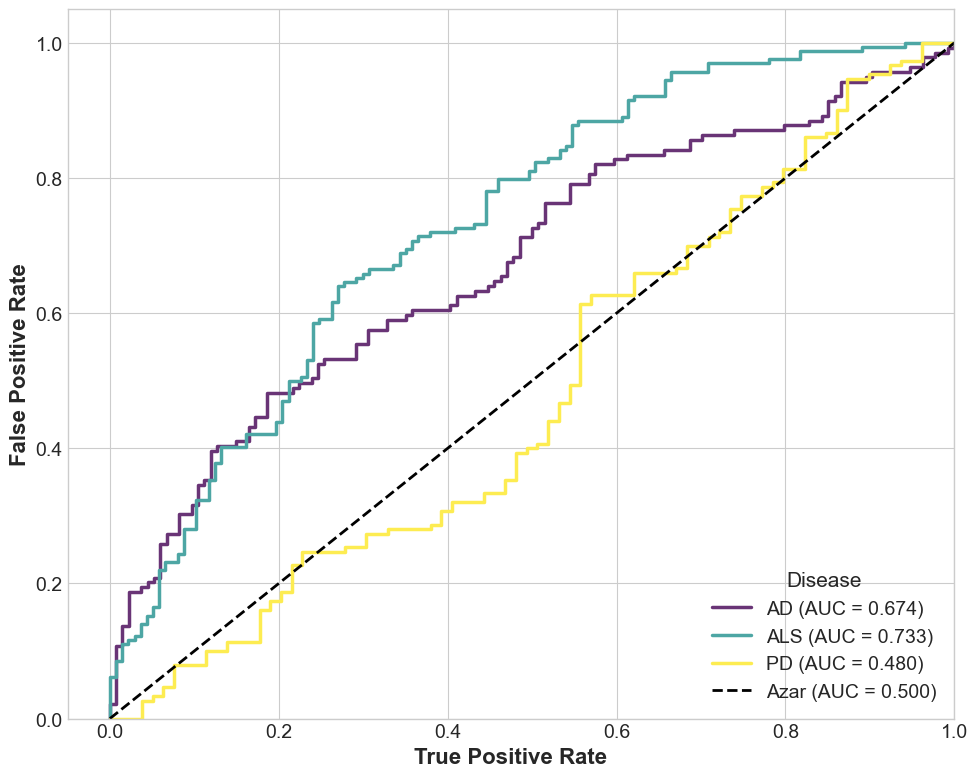

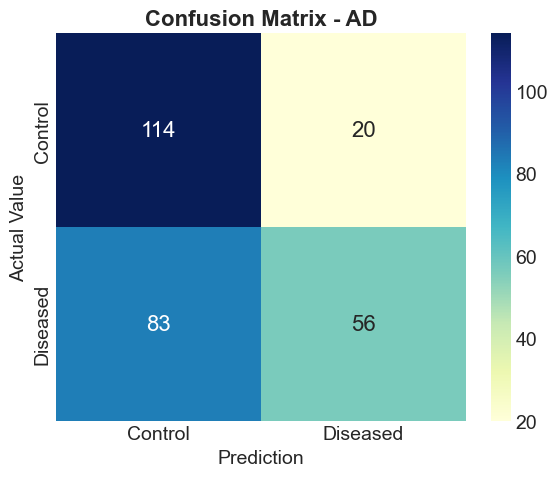

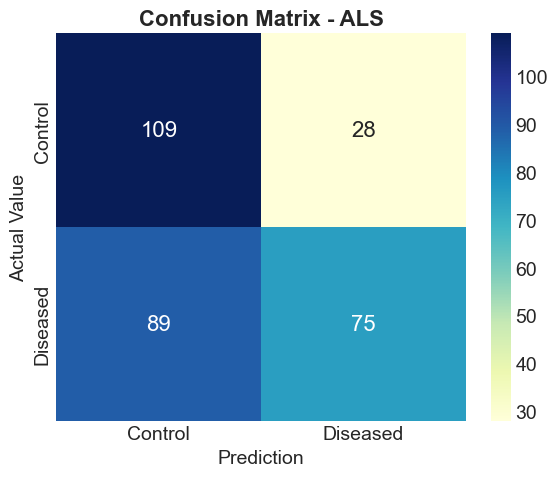

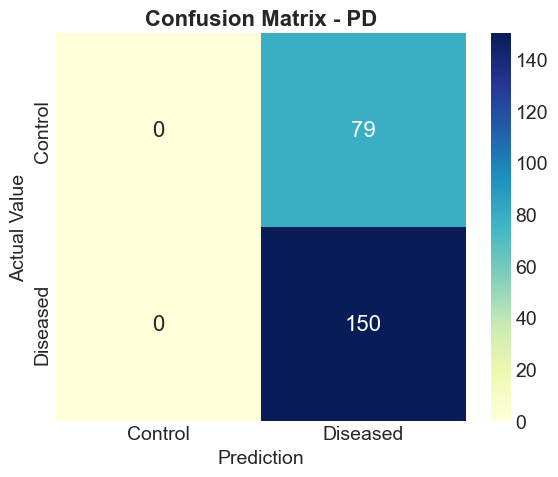

In [48]:
#We have the final model saved in final_models
#The first objective with the validation data is to answer the question: Does my model trained with cohort A work well with cohort B?

# Dictionary of validation datasets
validation_datasets = {
    'AD': data_AD_validation,  
    'ALS': data_ALS_validation, 
    'PD': data_PD_validation  
}

from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             precision_score, recall_score, f1_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

validation_results = {}

for disease, model in final_models.items():
    
    print(f"\n\n VALIDATING ORIGINAL MODEL FOR: {disease} ")
    
    # Obtain the corresponding validation data
    data_val = validation_datasets[disease]
    # We ALWAYS use the list of genes with which the model was trained.
    genes_originales_del_modelo = datasets[disease]['genes']
    # Special case for PD:
    if disease == 'PD' and 'TNFSF13B' not in data_val.columns:
        print("Special case for PD: Adding the missing 'TNFSF13B' column to the validation data.")
        data_val['TNFSF13B'] = 0

    
    X_val = data_val[genes_originales_del_modelo]
    y_val = data_val['class']
    
    predicciones = model.predict(X_val)
    predicciones_proba = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_val, predicciones)
    precision = precision_score(y_val, predicciones)
    recall = recall_score(y_val, predicciones)
    f1 = f1_score(y_val, predicciones)
    auc = roc_auc_score(y_val, predicciones_proba)
    cm = confusion_matrix(y_val, predicciones)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    fpr, tpr, _ = roc_curve(y_val, predicciones_proba)
    
    # Save results
    validation_results[disease] = {'fpr': fpr, 'tpr': tpr, 'auc': auc, 'cm': cm}
    
    # Report
    print(f" Results of {disease} in External Cohort ")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall (Sensitivity): {recall:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"AUC: {auc:.3f}")
    print("\nConfusion matrix:")
    print(cm)

#ROC curve charts
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'AD': '#693476', 'ALS': '#4DA6A4', 'PD': '#FDEC51'}

plt.figure(figsize=(10, 8))

for disease, results in validation_results.items():
    plt.plot(results['fpr'], results['tpr'], 
             color=colors.get(disease, 'gray'), # .get() to avoid errors if there are more diseases
             lw=2.5,
             label=f'{disease} (AUC = {results["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.500)') 
plt.xlim([-0.05, 1.0]) 
plt.ylim([0.0, 1.05]) 
plt.xlabel("True Positive Rate", fontsize=16, weight='bold') 
plt.ylabel("False Positive Rate", fontsize=16, weight='bold') 
#plt.title(" ", fontsize=18, weight='bold') 
plt.legend(loc="lower right", fontsize=14, title="Disease", title_fontsize=15) 
plt.tight_layout() 

plt.savefig('ROC_curves_validation.png', dpi=600, bbox_inches='tight')
plt.show()


# Confusion matrix graphs
for disease, results in validation_results.items():
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(results['cm'], annot=True, fmt="d", 
                cmap="YlGnBu",  
                xticklabels=['Control', 'Diseased'], 
                yticklabels=['Control', 'Diseased'],
                annot_kws={"size": 16}) 
    plt.title(f"Confusion Matrix - {disease}", fontsize=16, weight='bold')
    plt.xlabel("Prediction", fontsize=14)
    plt.ylabel("Actual Value", fontsize=14)
    plt.tight_layout()
    
    plt.savefig(f'matriz_confusion_validacion_{disease}.png', dpi=600, bbox_inches='tight')
    plt.show()


In [49]:
#In this second phase, we seek to answer: Are the important genes the same in cohort A and cohort B?
#To answer this question, we must forget the original models and retrain them with the new data.
#We will follow the same CV strategy defined at the beginning.
#We will use the dictionary with the validation datasets.

#CV Strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n\n RE-TRAINING MODELS WITH EXTERNAL DATA")

for disease, data_val in validation_datasets.items():

    print(f"\n\n Re-training Final Model for: {disease} ")
    
    genes_a_usar = datasets[disease]['genes']
    X_new = data_val[genes_a_usar]
    y_new = data_val['class']
    
    # New pipe
    pipe_new = Pipeline([
        ('scaler', StandardScaler()),
        ('logistic_lasso', LogisticRegressionCV(
            Cs=np.logspace(-3, 3, 50), 
            cv=cv_strategy, 
            penalty='l1', solver='liblinear',
            scoring='roc_auc', random_state=42, max_iter=5000, class_weight='balanced'
        ))
    ])
    
    pipe_new.fit(X_new, y_new)
    
    # New coefficients
    final_model_new = pipe_new.named_steps['logistic_lasso']
    coefficients = final_model_new.coef_[0]
    gene_importance = dict(zip(genes_a_usar, coefficients))
    sorted_genes = sorted(gene_importance.items(), key=lambda x: abs(x[1]), reverse=True)
    
    print(f"\nTop Genes Selected by the Re-trained Model in {disease}:")
    
    count_selected = 0
    for gene, coef in sorted_genes:
        if abs(coef) > 1e-6: # Umbral para considerar un gen como "seleccionado"
            print(f"{gene}: {coef:.4f}")
            count_selected += 1
            
    if count_selected == 0:
        print("No genes were selected by the model in this cohort.")



 RE-TRAINING MODELS WITH EXTERNAL DATA


 Re-training Final Model for: AD 

Top Genes Selected by the Re-trained Model in AD:
ITGAM: 0.4712
NKTR: 0.3225
RPL22: -0.2901
TAX1BP1: -0.2311


 Re-training Final Model for: ALS 

Top Genes Selected by the Re-trained Model in ALS:
TAX1BP1: 1.1268
CTSS: 0.8630
RPS6KB1: -0.7199
IL18: -0.6752
RBM25: -0.5921
TNFSF13B: 0.5568
PTEN: -0.5364
CSF1R: -0.4320
TPT1: 0.4040
LILRB2: -0.3364
ITGAM: 0.3046
RPL22: 0.2738
TLR4: 0.2703
PTPRC: -0.1793
FOS: -0.1707
NKTR: -0.1094
RPL15: 0.0722


 Re-training Final Model for: PD 

Top Genes Selected by the Re-trained Model in PD:
PTPRC: 0.1627
